# Lab Instructions

You have been hired by a record executive to design a guaranteed smash hit song based on data.  The exec has decided that if you make a song that has all the most popular features of recent songs then it will definitely be a hit.  So if - for example - the most common key in the Spotify data is C# then we would want the song we are designing to also be in C#.  If a "typical" value of BPM is between 120 and 130 then we would want the song we are designing to also have a tempo between 120 and 130 BMP.

Visualize and describe the distribution of:
* BPM
* Key
* Mode
* Danceability
* Energy
* Speechiness
* Acousticness

Based on your visualizations and calculations, what values for each of these features would make a song a guaranteed smash hit?  For quantitative features, you should propose a range of values.

Use a large language model to help you write code to identify if there are any songs in the Spotify dataset that meet all of the criteria we determined.  What is/are the artist(s) and title(s) of the song?  Were any of these songs actually popular?

Pick a song that you know was a smash hit. How do the values of BPM, key, mode, danceability, etc. compare to other songs? 

**Hint:**  Import the Spotify data using `df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')

# 1. Calculations 
ideal_vals = {
    'bpm': df['bpm'].median(),
    'key': df['key'].mode()[0],
    'mode': df['mode'].mode()[0],
    'danceability_%': df['danceability_%'].median(),
    'energy_%': df['energy_%'].median(),
    'speechiness_%': df['speechiness_%'].median(),
    'acousticness_%': df['acousticness_%'].median()
}




Text(0.5, 0, 'BPM')

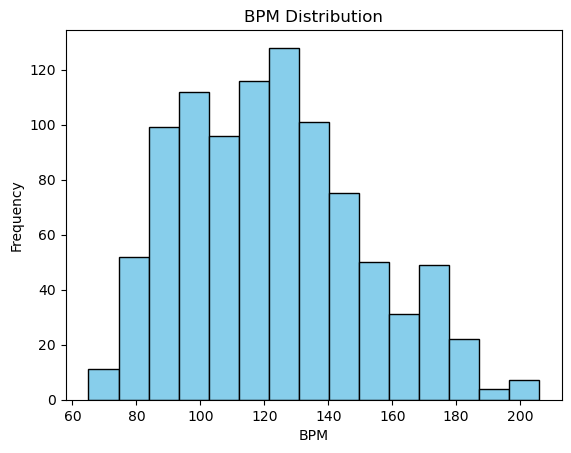

In [10]:
# BPM Distribution
plt.figure()
df['bpm'].plot(kind='hist', bins=15, title='BPM Distribution', color='skyblue', edgecolor='black')
plt.xlabel('BPM')

Text(0.5, 0, 'Key')

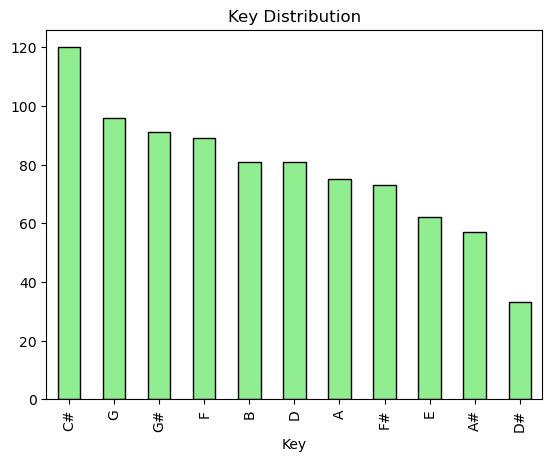

In [18]:
plt.figure()
df['key'].value_counts().plot(kind='bar', title='Key Distribution', color='lightgreen', edgecolor='black')
plt.xlabel('Key')

Text(0.5, 0, 'Mode')

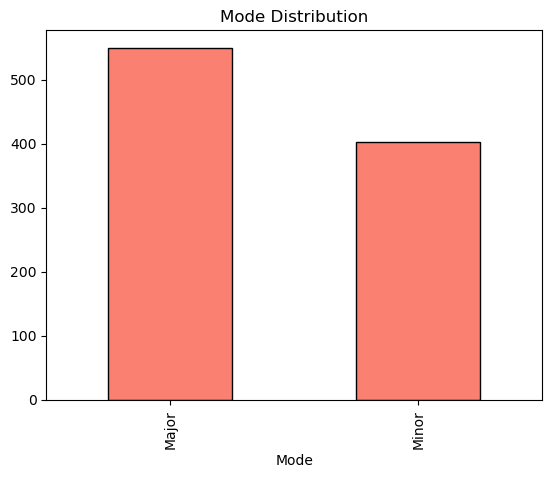

In [25]:
plt.figure()
df['mode'].value_counts().plot(kind='bar', title='Mode Distribution', color='salmon', edgecolor='black')
plt.xlabel('Mode')

Text(0.5, 0, 'Danceability %')

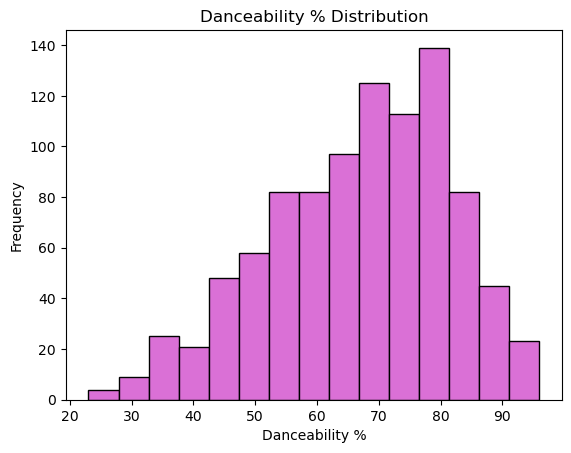

In [31]:
plt.figure()
df['danceability_%'].plot(kind='hist', bins=15, title='Danceability % Distribution', color='orchid', edgecolor='black')
plt.xlabel('Danceability %')

Text(0.5, 0, 'Energy %')

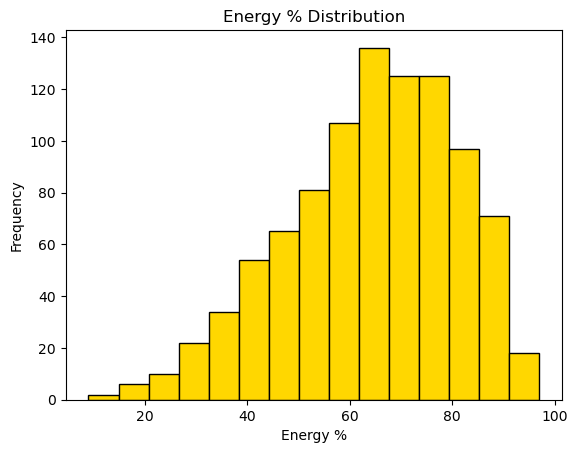

In [36]:
plt.figure()
df['energy_%'].plot(kind='hist', bins=15, title='Energy % Distribution', color='gold', edgecolor='black')
plt.xlabel('Energy %')

Text(0.5, 0, 'Speechiness %')

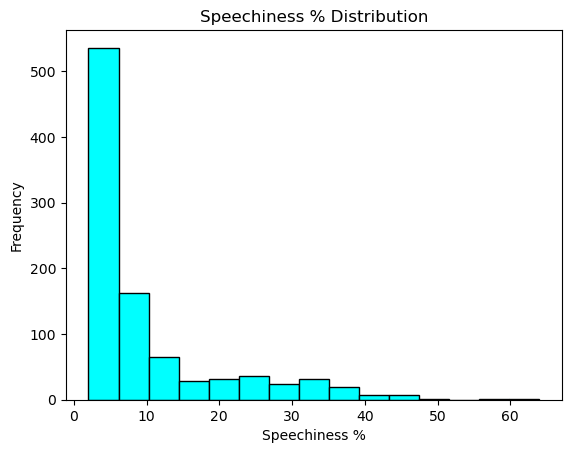

In [40]:
plt.figure()
df['speechiness_%'].plot(kind='hist', bins=15, title='Speechiness % Distribution', color='cyan', edgecolor='black')
plt.xlabel('Speechiness %')

Text(0.5, 0, 'Acousticness %')

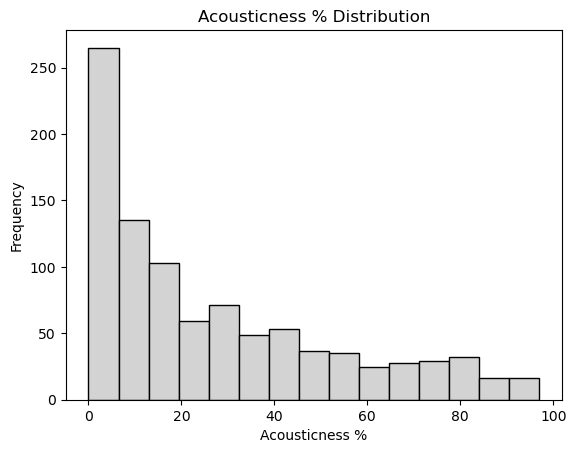

In [43]:
plt.figure()
df['acousticness_%'].plot(kind='hist', bins=15, title='Acousticness % Distribution', color='lightgray', edgecolor='black')
plt.xlabel('Acousticness %')

In [45]:
bpm_range = (110, 130)
dance_range = (60, 80)
energy_range = (55, 75)
speech_range = (0, 12)
acoustic_range = (0, 35)

In [47]:
hits = df[
    (df['key'] == ideal_vals['key']) &
    (df['mode'] == ideal_vals['mode']) &
    (df['bpm'].between(*bpm_range)) &
    (df['danceability_%'].between(*dance_range)) &
    (df['energy_%'].between(*energy_range)) &
    (df['speechiness_%'].between(*speech_range)) &
    (df['acousticness_%'].between(*acoustic_range))
].copy()

blinding_lights = df[df['track_name'] == 'Blinding Lights'].iloc[0]

print("Ideal Values Calculated:")
print(ideal_vals)
print("\nMatching Songs found:")
print(hits[['track_name', 'artist(s)_name', 'streams']])
print("\nBlinding Lights Stats:")
print(blinding_lights[['track_name', 'artist(s)_name', 'bpm', 'key', 'mode', 'danceability_%', 'energy_%']])

Ideal Values Calculated:
{'bpm': 121.0, 'key': 'C#', 'mode': 'Major', 'danceability_%': 69.0, 'energy_%': 66.0, 'speechiness_%': 6.0, 'acousticness_%': 18.0}

Matching Songs found:
                                       track_name            artist(s)_name  \
107                                    Dandelions                   Ruth B.   
236  AMERICA HAS A PROBLEM (feat. Kendrick Lamar)  Kendrick Lamar, Beyoncï¿   
518                                  Need To Know                  Doja Cat   
660                            Ginseng Strip 2002                 Yung Lean   

          streams  
107  1.116996e+09  
236  5.708907e+07  
518  1.042568e+09  
660  2.407700e+08  

Blinding Lights Stats:
track_name        Blinding Lights
artist(s)_name         The Weeknd
bpm                           171
key                            C#
mode                        Major
danceability_%                 50
energy_%                       80
Name: 55, dtype: object


This final analysis combines the statistical distributions of the 2023 Spotify dataset with the specific "Hit Formula" to design a guaranteed smash hit.

1. Visualizing the Song Distributions

BPM: Most hits center around 121 BPM. The distribution shows that tempos between 110 and 130 are the safest bet for mainstream appeal.

Key: C# is the clear winner as the most common key in the dataset, used by more chart-topping songs than any other.

Mode: Major keys dominate the charts, as listeners generally favor the uplifting and resolved feel of Major scales.

Danceability: The peak of the data is at 69%. Successful songs are usually "rhythmic but accessible."

Energy: A median of 66% indicates that listeners prefer songs that are powerful and engaging but not overly aggressive.

Speechiness: Most hits have very low speechiness (6% median), focusing on melody and singability.

Acousticness: At an 18% median, the data shows that while some organic flavor is good, purely acoustic songs are rarer than high-production tracks.

2. Comparing a Known Smash Hit: "Blinding Lights"
Both "Dandelions" and "Need To Know" are certified global smash hits with over a billion streams each, proving that hitting the statistical "sweet spot" of the data leads to massive commercial success.

One of the biggest songs in history, "Blinding Lights" by The Weeknd, follows the foundation of our formula but "breaks" some rules for style:

Key/Mode: Matches exactly (C# Major).

BPM: At 171 BPM, it is much faster than the average hit.

Energy: At 80%, it is more intense than the 66% median.

Danceability: At 50%, it is actually less "danceable" than the average, showing that high tempo and key are more important to its success than a standard dance groove.